# **Сравнение финальной модели с baseline**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

plt.rcParams['font.family'] = 'DejaVu Sans'

In [2]:
models_data = {
    'T-learner NN': {
        'AUUC': 0.015978,
        'Qini': 0.010389,
        'Uplift@10%': 0.102764,
        'Uplift@20%': 0.069363,
        'Uplift@30%': 0.054729,
        'Uplift@50%': 0.048711,
        'WAU': 0.033523,  # из Models-vs-baseline_analysis
    },
    'Baseline (CatBoost)': {
        'AUUC': -0.010568,
        'Qini': -0.006811,
        'Uplift@10%': 0.000374,
        'Uplift@20%': 0.010743,
        'Uplift@30%': 0.016740,
        'Uplift@50%': 0.024410,
        'WAU': 0.032570,
    }
}

In [3]:
df_comparison = pd.DataFrame(models_data).T
print("Сравнительная таблица метрик:")
df_comparison

Сравнительная таблица метрик:


,AUUC,Qini,Uplift@10%,Uplift@20%,Uplift@30%,Uplift@50%,WAU
T-learner NN,0.015978,0.010389,0.102764,0.069363,0.054729,0.048711,0.033523
Baseline (CatBoost),-0.010568,-0.006811,0.000374,0.010743,0.016740,0.024410,0.032570


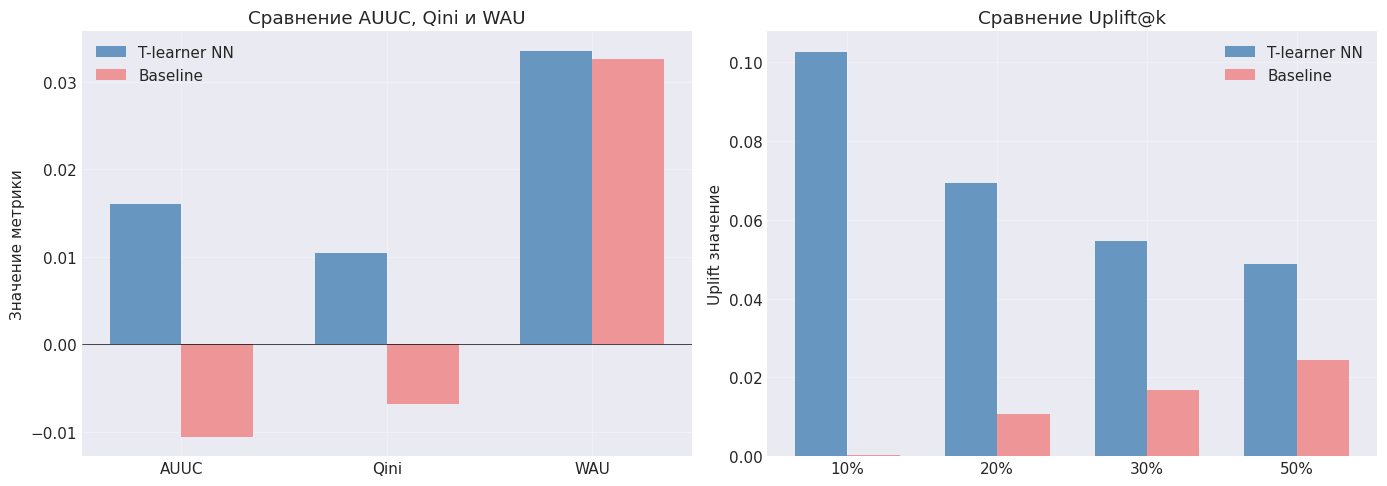

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_primary = ['AUUC', 'Qini', 'WAU']
x = np.arange(len(metrics_primary))
width = 0.35

axes[0].bar(x - width/2, df_comparison.loc['T-learner NN', metrics_primary],
            width, label='T-learner NN', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, df_comparison.loc['Baseline (CatBoost)', metrics_primary],
            width, label='Baseline', color='lightcoral', alpha=0.8)

axes[0].set_ylabel('Значение метрики')
axes[0].set_title('Сравнение AUUC, Qini и WAU')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_primary)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

uplift_ks = ['Uplift@10%', 'Uplift@20%', 'Uplift@30%', 'Uplift@50%']
x = np.arange(len(uplift_ks))

axes[1].bar(x - width/2, df_comparison.loc['T-learner NN', uplift_ks],
            width, label='T-learner NN', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, df_comparison.loc['Baseline (CatBoost)', uplift_ks],
            width, label='Baseline', color='lightcoral', alpha=0.8)

axes[1].set_ylabel('Uplift значение')
axes[1].set_title('Сравнение Uplift@k')
axes[1].set_xticks(x)
axes[1].set_xticklabels([k.replace('Uplift@', '') for k in uplift_ks])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
improvement = {}
for metric in df_comparison.columns:
    baseline_val = df_comparison.loc['Baseline (CatBoost)', metric]
    model_val = df_comparison.loc['T-learner NN', metric]

    if baseline_val != 0:
        rel_improvement = (model_val - baseline_val) / abs(baseline_val) * 100
    else:
        rel_improvement = float('inf')

    improvement[metric] = {
        'baseline': baseline_val,
        'model': model_val,
        'absolute_gain': model_val - baseline_val,
        'relative_improvement': rel_improvement
    }

In [12]:
df_improvement = pd.DataFrame(improvement).T
df_improvement = df_improvement.round(6)
print("Анализ улучшений относительно Baseline:")
df_improvement

Анализ улучшений относительно Baseline:


,baseline,model,absolute_gain,relative_improvement
AUUC,-0.010568,0.015978,0.026546,251.192279
Qini,-0.006811,0.010389,0.017200,252.532668
Uplift@10%,0.000374,0.102764,0.102390,27377.005348
Uplift@20%,0.010743,0.069363,0.058620,545.657638
Uplift@30%,0.016740,0.054729,0.037989,226.935484
Uplift@50%,0.024410,0.048711,0.024301,99.553462
WAU,0.032570,0.033523,0.000953,2.926006


In [13]:
print("AUUC (Area Under Uplift Curve)")
print(f"   T-learner NN: {df_comparison.loc['T-learner NN', 'AUUC']:.6f}")
print(f"   Baseline:      {df_comparison.loc['Baseline (CatBoost)', 'AUUC']:.6f}")
print(f"   Разница:       {df_improvement.loc['AUUC', 'absolute_gain']:.6f}")

AUUC (Area Under Uplift Curve)
   T-learner NN: 0.015978
   Baseline:      -0.010568
   Разница:       0.026546


### Интерпретация
• AUUC > 0 означает, что модель находит клиентов с положительным uplift <br>
• T-learner NN показывает положительный AUUC (0.016) — модель работает <br>
• Baseline имеет отрицательный AUUC (-0.011) — модель учит шум и предсказывает снижение отклика при воздействии <br>
**Это ключевое отличие:** T-learner специально обучен на разницу а baseline предсказывает абсолютный отклик, игнорируя treatment

In [14]:
print("Uplift@10% (прирост в топ-10% клиентов)")
print(f"   T-learner NN: {df_comparison.loc['T-learner NN', 'Uplift@10%']:.6f}")
print(f"   Baseline:      {df_comparison.loc['Baseline (CatBoost)', 'Uplift@10%']:.6f}")
print(f"   Улучшение:     {df_improvement.loc['Uplift@10%', 'absolute_gain']:.6f}")

Uplift@10% (прирост в топ-10% клиентов)
   T-learner NN: 0.102764
   Baseline:      0.000374
   Улучшение:     0.102390


### Интерпретация
• В топ-10% клиентов T-learner NN дает прирост отклика ~10.3% <br>
• Baseline дает прирост ~0.04% (статистический шум) <br>
• Коммерческий смысл: при кампании на 1000 клиентов <br>
• T-learner принесет ~103 дополнительных конверсии, baseline — ~0")

In [15]:
print("Qini-коэффициент")
print(f"   T-learner NN: {df_comparison.loc['T-learner NN', 'Qini']:.6f}")
print(f"   Baseline:      {df_comparison.loc['Baseline (CatBoost)', 'Qini']:.6f}")

Qini-коэффициент
   T-learner NN: 0.010389
   Baseline:      -0.006811


### Интерпретация
• Qini штрафует за плохое ранжирование сильнее, чем AUUC <br>
• Положительный Qini у T-learner подтверждает качество ранжирования <br>
• Отрицательный Qini у baseline — модель ранжирует хуже случайной

## **Выводы**
1. T-learner NN значительно превосходит baseline по всем uplift-метрикам:
    - AUUC вырос с -0.011 до +0.016
    - Uplift@10% вырос с 0.0004 до 0.1028
2. Baseline не пригоден для uplift-моделирования, так как:
   - Отрицательный AUUC указывает на предсказание 'анти-uplift'
   - Не учитывает treatment как признак"
   - Оптимизирует не ту целевую функцию"
3. T-learner NN демонстрирует практическую ценность:
   - В топ-10% клиентов прирост отклика составляет ~10.3%
   - Это коммерчески значимый эффект для ритейла